# Base de Reglas | Aspiradora

## Sobre

El seguiente cuaderno tiene como objetivo hacer una base de reglas para un controlador difuso para el entorno de una aspiradora. 

## Variables de entrada

- Suciedad: [`muy_sucio`, `sucio`, `algo_sucio`, `casi_limpio`, `limpio`]
- Superficie: [`madera`, `caucho`, `alfombra`]

## Variables de salida

- Potencia: [`muy_debil`, `debil`, `normal`, `fuerte`, `muy_fuerte`]

### Instalaciones

In [ ]:
!pip install fuzzylogic numpy pandas matplotlib

#### Importes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fuzzylogic.classes import Domain, Rule
from fuzzylogic.functions import triangular, bounded_sigmoid

### Dominios

El universo de discurso de nuestro dominio son los posibles estados que el entorno de una aspiradora puede encontrar. Así como vemos en la tabla, consideramos 5 estados de limpieza y 3 superficies acceptables por el agente que pueden variar en 15 posibles ayustes de la potencia de la aspiradora. Por lo tanto, tenemos aquí un universo con 2 dominios que van a entrar a los sensores del agente y 1 que será seleccionado para ejecutar la acción de aspirar.

In [2]:
# Dominios de entrada y salida
suciedad = Domain("Suciedad", low=0, high=100)
superficie = Domain("Superficie", low=0, high=2)
potencia = Domain("Potencia", low=0, high=100)

### Conjuntos de Entrada

#### Suciedad

Para representar nuestras variables linguística - `Suciedad`, y como veremos más adiante, `Potencia` -, hemos creado para cada estado de limpieza sus conjuntos representados por una función de pertinencia. Aquí hemos utilizado la función `bounded_sigmoid`, que es utilizada para representar membransías difusas muy suaves de valores que pertenencen parcialmente a un dominio, adémas de presentar una major continuidad en comparacióna funciones `R` y `S`.

Así que el axis `y`, que va de `0` a `1` demonstra el grado que una superficie puede o no estar en este estado, o sea, el grado de pertenencia. En este domínio tenemos un rango total de `0` a `100` a ser encontrado por la aspiradora, donde hemos definido que:

- De `0` a `20`: `limpio`
- De `20` a `40`: `casi limpio`
- De `40` a `60`: `algo sucio`
- De `60` a `80`: `sucio`
- De `80` a `100`: `muy sucio`


##### Limpio

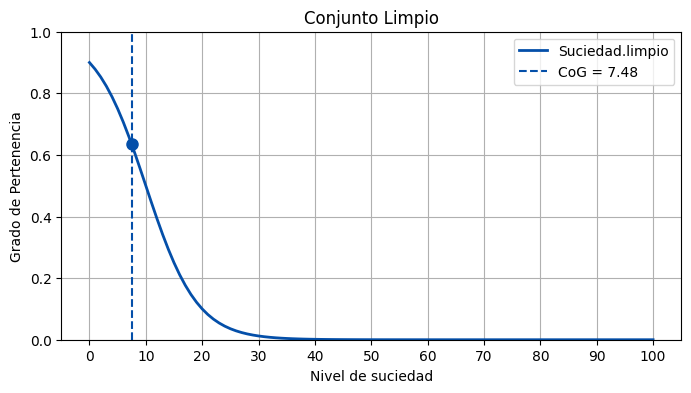

In [3]:
# Conjunto y pertenencia
suciedad.limpio = bounded_sigmoid(0, 20, inverse=True)

# Gráfico
plt.figure(figsize=(8, 4))
suciedad.limpio.plot()

plt.title("Conjunto Limpio")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

##### Casi Limpio

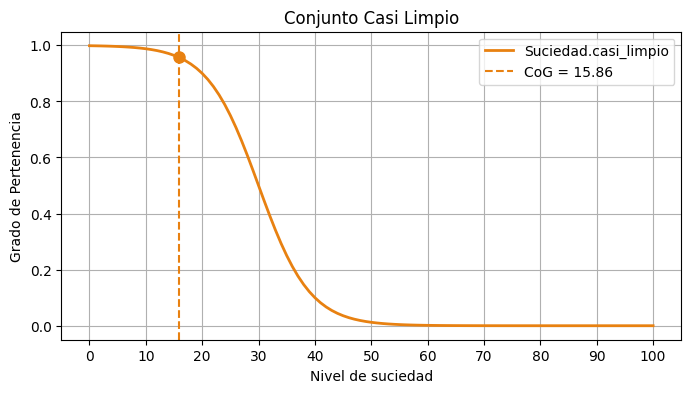

In [4]:
# Conjunto y pertinencia
suciedad.casi_limpio = bounded_sigmoid(20, 40, inverse=True)

plt.figure(figsize=(8, 4))
suciedad.casi_limpio.plot()
plt.title("Conjunto Casi Limpio")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

##### Algo Sucio

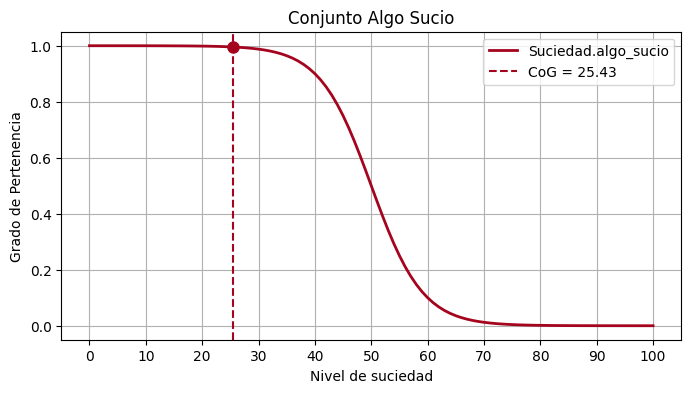

In [5]:
# Conjunto y pertenencia
suciedad.algo_sucio = bounded_sigmoid(40, 60, inverse=True)

# Plota
plt.figure(figsize=(8, 4))
suciedad.algo_sucio.plot()
plt.title("Conjunto Algo Sucio")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

##### Sucio

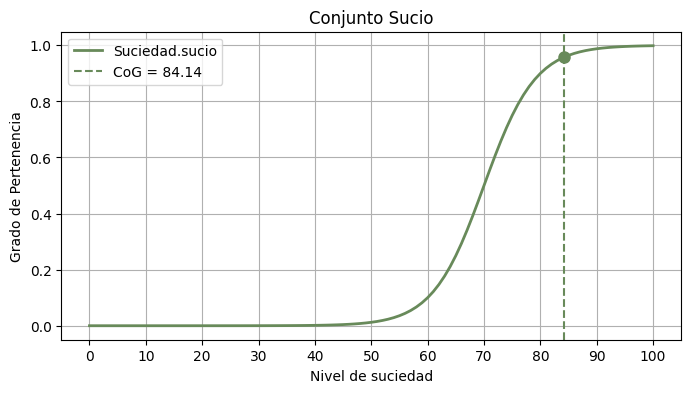

In [6]:
# Conjunto y pertenencia
suciedad.sucio = bounded_sigmoid(60, 80)

# Plota
plt.figure(figsize=(8, 4))
suciedad.sucio.plot()
plt.title("Conjunto Sucio")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

##### Muy Sucio

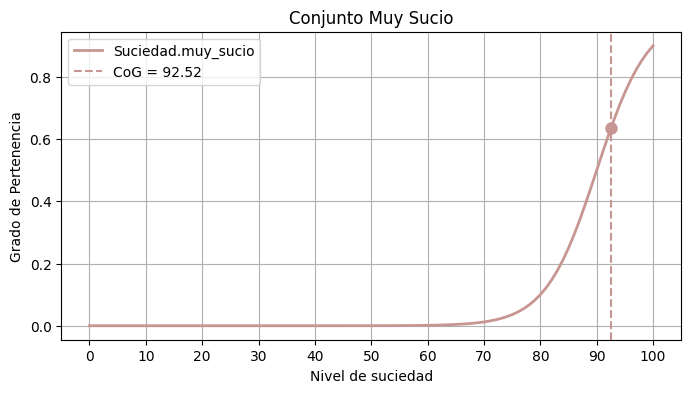

In [7]:
# Conjunto y pertenencia
suciedad.muy_sucio = bounded_sigmoid(80, 100)

# Plota
plt.figure(figsize=(8, 4))
suciedad.muy_sucio.plot()
plt.title("Conjunto Muy Sucio")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

#### Todos los Conjuntos Suciedad

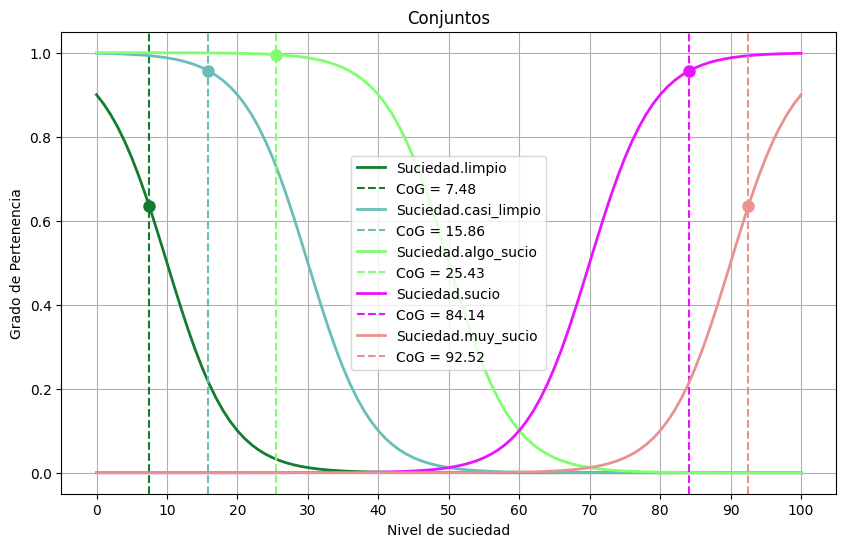

In [8]:
# Plota
plt.figure(figsize=(10, 6))
suciedad.limpio.plot()
suciedad.casi_limpio.plot()
suciedad.algo_sucio.plot()
suciedad.sucio.plot()
suciedad.muy_sucio.plot()
plt.title("Conjuntos")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Grado de Pertenencia")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

#### Superficie

Una forma de hacer con que el agente reconozca los 3 tipos de superficies, y como vemos abajo, es variar lo 3 estados numericos por atribuiciones, donde: 

- `0` representa la `madera`
- `1` representa el `caucho`
- `2` representa la `alfombra`

Para lograr la fuzzificación de los conjuntos, hemos utilizado aqui el método `triangular` de la biblioteca `fuzzylogic`, donde son pasados el início y fin de la trangulación, resultando en el gráfico presentado abajo.

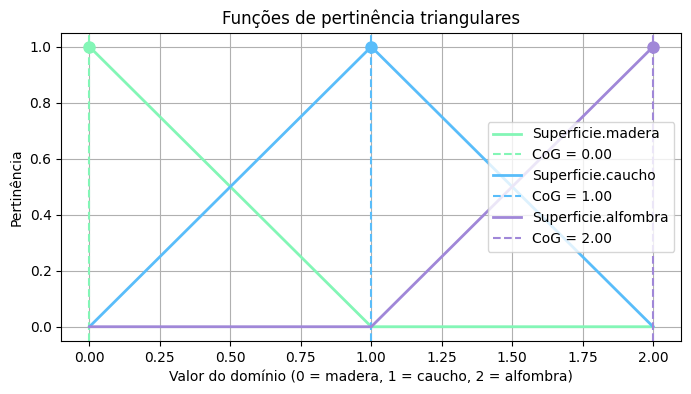

In [11]:
# Define funções de pertinência triangulares
superficie.madera = triangular(-1.0, 1)
superficie.caucho = triangular(0, 2)
superficie.alfombra = triangular(1, 3)

# Plota
plt.figure(figsize=(8, 4))
superficie.madera.plot()
superficie.caucho.plot()
superficie.alfombra.plot()
plt.xlabel("Valor do domínio (0 = madera, 1 = caucho, 2 = alfombra)")
plt.ylabel("Pertinência")
plt.title("Funções de pertinência triangulares")
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

### Conjunto de Salida

#### Potencia

De la misma forma como ha sido determinado para la suciedad, la potencia puede variar entre los seguientes rangos:

- `0` a `20`: `muy débil`
- `20` a `40`: `débil`
- `40` a `60`: `normal`
- `60` a `80`: `fuerte`
- `80` a `100`: `muy fuerte`


##### Muy Débil

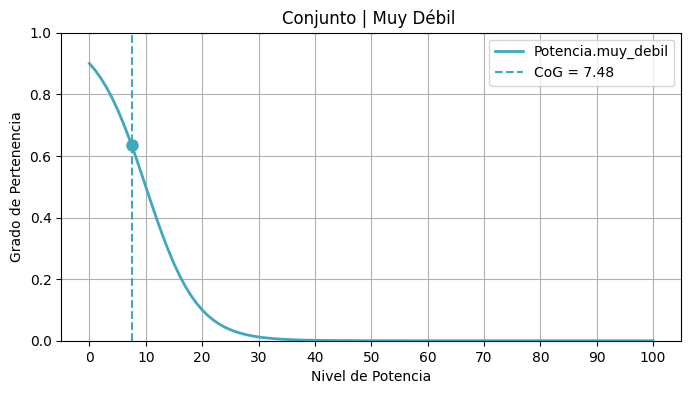

In [12]:
# Para que la función tenga su altura = 1, el Dominio de la potencia deberá empezar en  
# potencia = Domain("Potencia", low=-20, high=100)
# Padrón
# potencia = Domain("Potencia", low=0, high=100)

# Conjunto
potencia.muy_debil = bounded_sigmoid(0, 20, inverse=True)

# Gráfico
plt.figure(figsize=(8, 4))
potencia.muy_debil.plot()

plt.title("Conjunto | Muy Débil ")
plt.xlabel("Nivel de Potencia")
plt.ylabel("Grado de Pertenencia")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

##### Débil

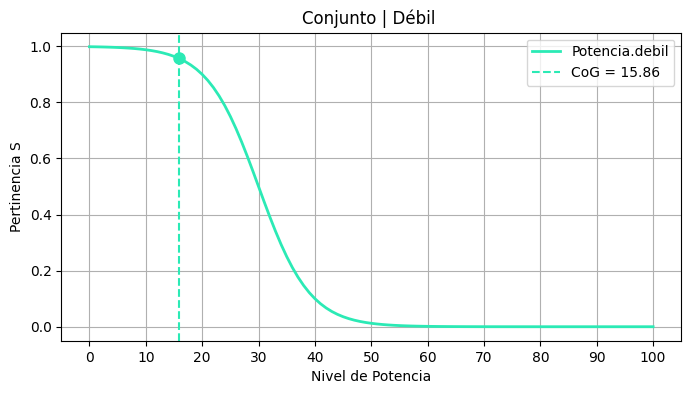

In [13]:
potencia.debil = bounded_sigmoid(20, 40, inverse=True)

# Gráfico
plt.figure(figsize=(8, 4))
potencia.debil.plot()

plt.title("Conjunto | Débil ")
plt.xlabel("Nivel de Potencia")
plt.ylabel("Pertinencia S")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)
plt.legend()

##### Normal

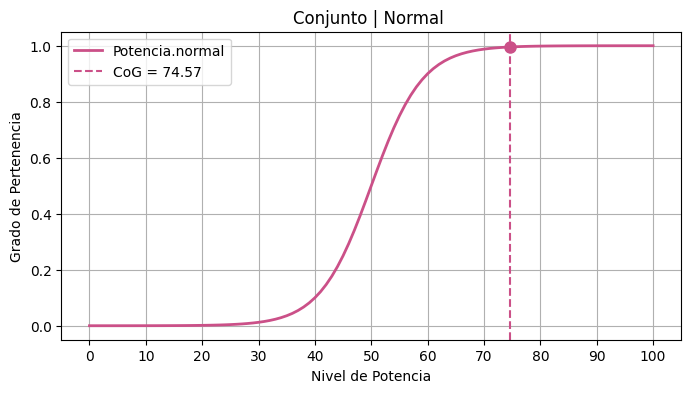

In [14]:
potencia.normal = bounded_sigmoid(40, 60)

# Gráfico
plt.figure(figsize=(8, 4))
potencia.normal.plot()

plt.title("Conjunto | Normal ")
plt.xlabel("Nivel de Potencia")
plt.ylabel("Grado de Pertenencia")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)
plt.legend()

##### Fuerte

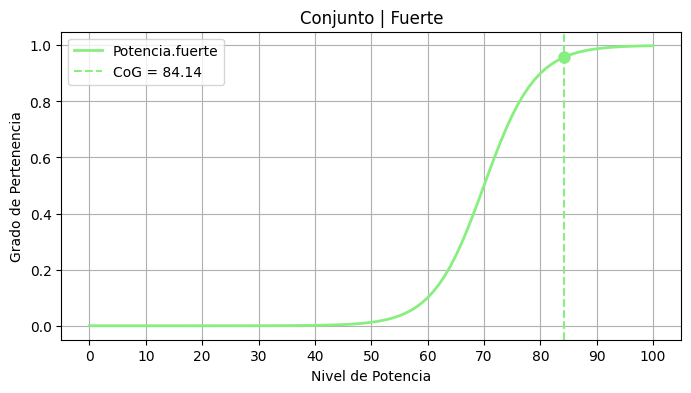

In [15]:
potencia.fuerte = bounded_sigmoid(60, 80)
# Gráfico
plt.figure(figsize=(8, 4))
potencia.fuerte.plot()

plt.title("Conjunto | Fuerte")
plt.xlabel("Nivel de Potencia")
plt.ylabel("Grado de Pertenencia")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)
plt.legend()

##### Muy Fuerte

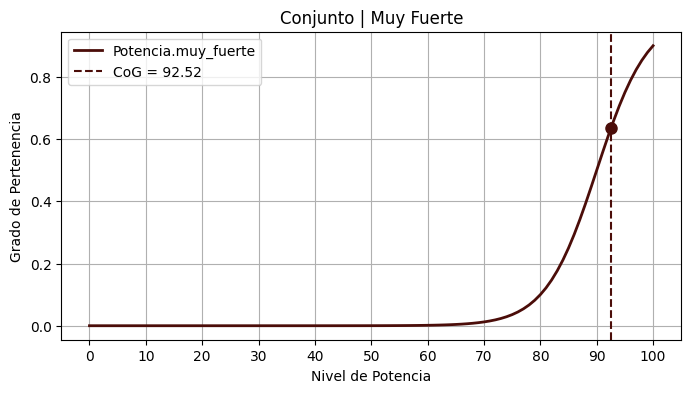

In [16]:
potencia.muy_fuerte = bounded_sigmoid(80, 100)
# Gráfico
plt.figure(figsize=(8, 4))
potencia.muy_fuerte.plot()

plt.title("Conjunto | Muy Fuerte")
plt.xlabel("Nivel de Potencia")
plt.ylabel("Grado de Pertenencia")
# Define ticks de 10 em 10 para x
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)
plt.legend()

#### Todos los conjuntos de Potencia

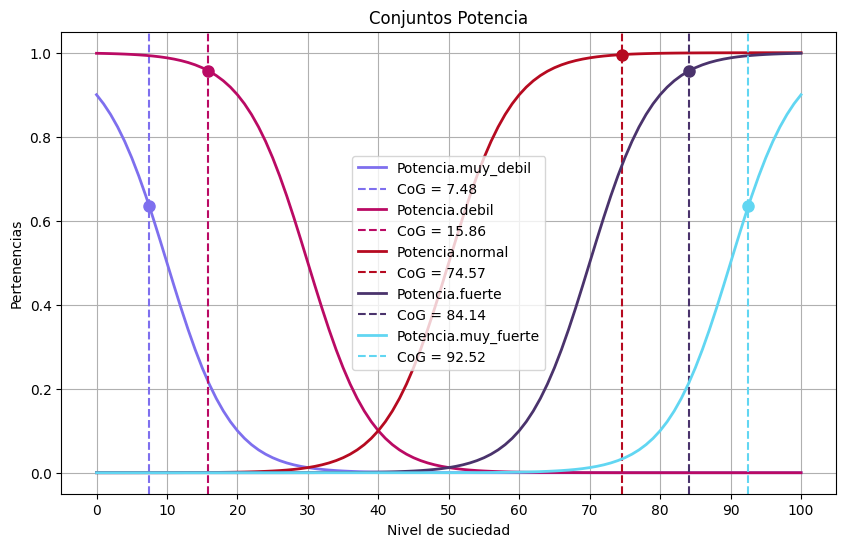

In [17]:
# Plota
plt.figure(figsize=(10, 6))
potencia.muy_debil.plot()
potencia.debil.plot()
potencia.normal.plot()
potencia.fuerte.plot()
potencia.muy_fuerte.plot()
plt.title("Conjuntos Potencia")
plt.xlabel("Nivel de suciedad")
plt.ylabel("Pertenencias")
plt.xticks(np.arange(0, 101, 10))
plt.grid(True)

### Reglas

La base de reglas ha sido quitada de esta tabla:

|  | Limpio | Casi limpio | Algo sucio | Sucio | Muy sucio |
| --- | --- | --- | --- | --- | --- | 
| **Madera (0)** | Muy débil | Muy débil | Débil | Normal | Fuerte |
| **Caucho (1)** | Muy débil | Débil | Normal | Fuerte | Muy fuerte |
| **Alfombra (2)** | Débil | Normal | Normal | Fuerte | Muy fuerte |

Que posteriormente ha sido transformada y relacionada en las siguientes reglas difusas:

- R1: SI suciedad==muy_sucia y superficie==madera ENTONCES potencia==fuerte.
- R2: SI suciedad==sucia y superficie==madera ENTONCES potencia==normal.
- R3: SI suciedad==algo_sucia y superficie==madera ENTONCES potencia==debil.
- R4: SI suciedad==(casi_limpia o limpio) y superficie==madera ENTONCES potencia==muy_debil.
- R5: SI suciedad==muy_sucio y superficie==caucho ENTONCES potencia==muy_fuerte.
- R6: SI suciedad==sucio y superficie==caucho ENTONCES potencia==fuerte.
- R7: SI suciedad==algo_sucio y superficie==caucho ENTONCES potencia==normal.
- R8: SI suciedad==casi_limpio y superficie==caucho ENTONCES potencia==debil.
- R9: SI suciedad==limpio y superficie==caucho ENTONCES potencia==muy_debil.
- R10: SI suciedad==muy_sucio y superficie==alfombra ENTONCES potencia==muy_fuerte.
- R11: SI suciedad==sucio y superficie==alfombra ENTONCES potencia==fuerte.
- R12: SI suciedad==(casi_limpio o algo_sucio) y superficie==alfombra ENTONCES potencia==normal.
- R13: SI suciedad==limpio y superficie==alfombra ENTONCES potencia==debil.


#### Madera

In [18]:
# Reglas para madera (0)
R1 = Rule({(suciedad.muy_sucio, superficie.madera): potencia.fuerte})
R2 = Rule({(suciedad.sucio, superficie.madera): potencia.normal})
R3 = Rule({(suciedad.algo_sucio, superficie.madera): potencia.debil})
R4 = Rule({(suciedad.casi_limpio | suciedad.limpio, superficie.madera): potencia.muy_debil})

#### Caucho

In [19]:
# Reglas para caucho (1)
R5 = Rule({(suciedad.muy_sucio, superficie.caucho): potencia.muy_fuerte})
R6 = Rule({(suciedad.sucio, superficie.caucho): potencia.fuerte})
R7 = Rule({(suciedad.algo_sucio, superficie.caucho): potencia.normal})
R8 = Rule({(suciedad.casi_limpio, superficie.caucho): potencia.debil})
R9 = Rule({(suciedad.limpio, superficie.caucho): potencia.muy_debil})

#### Alfombra y Conjunto de Reglas `rules`

In [20]:
# Reglas para alfombra (2)
R10 = Rule({(suciedad.muy_sucio, superficie.alfombra): potencia.muy_fuerte})
R11 = Rule({(suciedad.sucio, superficie.alfombra): potencia.fuerte})
R12 = Rule({(suciedad.casi_limpio | suciedad.algo_sucio, superficie.alfombra): potencia.normal})
R13 = Rule({(suciedad.limpio, superficie.alfombra): potencia.debil})

rules = R1 | R2 | R3 | R4 | R5 | R6 | R7 | R8 | R9 | R10 | R11 | R12 | R13 

## Ejemplo de ejecución

Para hacermos el test del programa pasamos las entradas a la instancia `rules` que vá a retornar la potencia estimada de acuerdo con las definiciones del conjunto. 

In [26]:
entrada = {suciedad: 70, superficie: 2}
resultado = rules(entrada)
print(f"Potencia estimada: {resultado:.2f}")

print("\nGrados de pertenencia en conjuntos de salida (Potencia):")

# Avaliar grau de pertença do resultado em cada conjunto fuzzy de potência
for label, fuzzy_set in potencia._sets.items():
    grado = fuzzy_set(resultado)
    print(f"  - {label}: {grado:.2f}")

Potencia estimada: 84.11

Grados de pertenencia en conjuntos de salida (Potencia):
  - muy_debil: 0.00
  - debil: 0.00
  - normal: 1.00
  - fuerte: 0.96
  - muy_fuerte: 0.22
